LFC columns: ['log2FoldChange_rep1', 'log2FoldChange_rep2', 'log2FoldChange_rep3']
SE columns: ['lfcSE_rep1', 'lfcSE_rep2', 'lfcSE_rep3']


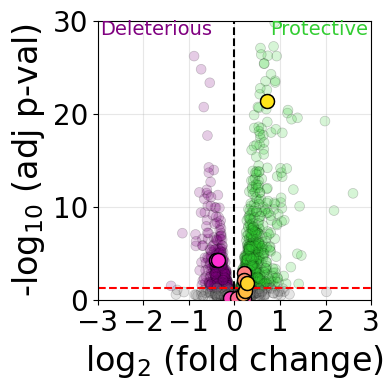


Total genes: 2401
Significantly up (padj < 0.05, LFC > 0): 642
Significantly down (padj < 0.05, LFC < 0): 334


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Templates 1-11
row_order = [
    'syn_LEA_1',
    'At2g46140_tile7',
    'TgL_8x',
    'Os_LEA_or3__Kappa_up_2_',
    'CAHS_68135_tile4',
    'A0A438HAK2',
    'Asyn_isoform_5',
    'A0A1U8F7A1',
    'Os_LEA_or6',
    'Os_LEA_or4',
    'A0A4D6M434',
]

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    new_cmap = LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

spring_cmap = plt.cm.spring
truncated_spring = truncate_colormap(spring_cmap, 0.10, 0.90)  # Remove 15% from each end
colors = {origin: truncated_spring(i / (len(row_order) - 1)) for i, origin in enumerate(row_order)}

# Load data
df1 = pd.read_csv('/../../Data/Figure_5/sequencing_data_all.csv')

# Identify columns for each replicate
lfc_cols = sorted([c for c in df1.columns if c.startswith('log2FoldChange_rep') 
                   and c[-1] in ['1', '2', '3']])
se_cols = sorted([c for c in df1.columns if c.startswith('lfcSE_rep') 
                  and c[-1] in ['1', '2', '3']])

print(f"LFC columns: {lfc_cols}")
print(f"SE columns: {se_cols}")

# Extract data
lfc_data = df1[lfc_cols].values
se_data = df1[se_cols].values

# Calculate inverse-variance weights
weights = 1 / (se_data ** 2)

# Weighted mean LFC
weighted_lfc = np.nansum(weights * lfc_data, axis=1) / np.nansum(weights, axis=1)

# Pooled SE of weighted mean
pooled_se = 1 / np.sqrt(np.nansum(weights, axis=1))

# Z-score and p-values
z_scores = weighted_lfc / pooled_se
pvalues = 2 * stats.norm.sf(np.abs(z_scores))

# Add to dataframe
df1['weighted_log2FC'] = weighted_lfc
df1['pooled_SE'] = pooled_se
df1['z_score'] = z_scores
df1['pvalue'] = pvalues

# Multiple testing correction
valid_mask = np.isfinite(df1['pvalue'])
_, padj_values, _, _ = multipletests(df1.loc[valid_mask, 'pvalue'], method='fdr_bh')
df1['padj'] = np.nan
df1.loc[valid_mask, 'padj'] = padj_values
df1['neg_log10_padj'] = -np.log10(df1['padj'])

# Assign colors based on significance
df1['color'] = 'grey'
df1.loc[(df1['neg_log10_padj'] > -np.log10(0.05)) & (df1['weighted_log2FC'] > 0), 'color'] = 'limegreen'
df1.loc[(df1['neg_log10_padj'] > -np.log10(0.05)) & (df1['weighted_log2FC'] < 0), 'color'] = 'purple'

# --- Volcano Plot (Square) ---
fig, ax = plt.subplots(figsize=[4, 4])

# Create volcano plot
ax.scatter(df1['weighted_log2FC'], df1['neg_log10_padj'], alpha=0.2, s=50,
           c=df1['color'], edgecolors='k', linewidths=0.5)

# Overlay original_sequence points with rainbow colors
for origin in row_order:
    wt_id = f'original_sequence_-_{origin}'
    wt = df1[df1['Sequence_ID'] == wt_id]
    if len(wt) > 0:
        ax.scatter(wt['weighted_log2FC'], wt['neg_log10_padj'], 
                   alpha=1.0, s=100, c=[colors[origin]], edgecolors='k', 
                   linewidths=1, zorder=10)

# Add horizontal line at -log10(0.05)
ax.axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=1.5, label='p = 0.05')

# Add vertical line at 0
ax.axvline(x=0, color='k', linestyle='--', linewidth=1.5, label='log2FC = 0')

ax.set_xlabel('log$_2$ (fold change)', fontsize=24)
ax.set_ylabel('-log$_{10}$ (adj p-val)', fontsize=24)
ax.grid(True, alpha=0.3)
ax.text(0.99, 0.95, 'Protective', color='limegreen', fontsize=14, transform=ax.transAxes, ha='right')
ax.text(0.01, 0.95, 'Deleterious', color='purple', fontsize=14, transform=ax.transAxes, ha='left')
ax.set_xlim(-3, 3)
ax.set_ylim(0, 30)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.tick_params(axis='both', which='major', labelsize=20)

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
#plt.savefig('volcano_weighted_square.svg', format='svg', bbox_inches='tight')
#plt.savefig('volcano_weighted_square.png', dpi=300, bbox_inches='tight')
plt.show()